In [11]:
# Cell 1 — Install
!pip install peft -q

In [12]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: Tesla T4


In [13]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import sys
from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/image_realness_project")
sys.path.insert(0, str(PROJECT))

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [15]:
from core.models.joint_model import JointModel

joint_model = JointModel(use_pretrained_backbones=True).to(device)
state = torch.load(PROJECT / "checkpoints" / "JOINT_2024.pth", map_location=device)
joint_model.load_state_dict(state)
joint_model.eval()
print("JOINT loaded")

JOINT loaded


In [16]:
# Cell 2 — Setup
import sys
from pathlib import Path
import torch

PROJECT = Path("/content/drive/MyDrive/image_realness_project")
sys.path.insert(0, str(PROJECT))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from diffusers import StableDiffusionPipeline, DDIMScheduler
from core.models.joint_model import JointModel
from core.guidance.rationality_guidance import RationalityGuidanceScorer

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe.safety_checker = None
pipe = pipe.to(device)

joint_model = JointModel(use_pretrained_backbones=True).to(device)
state = torch.load(PROJECT / "checkpoints" / "JOINT_2024.pth", map_location=device)
joint_model.load_state_dict(state)
joint_model.eval()

scorer = RationalityGuidanceScorer(joint_model).to(device)
scorer.eval()
print("Ready")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ready


In [18]:
!pip install torchao --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 57.7 MB/s eta 0:00:00


In [20]:
# Cell 3 — Inject LoRA
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)

pipe.unet = get_peft_model(pipe.unet, lora_config)
pipe.unet.print_trainable_parameters()

trainable_params = [p for p in pipe.unet.parameters() if p.requires_grad]
for p in trainable_params:
    p.data = p.data.to(torch.float32)

from torch.optim import AdamW
optimizer = AdamW(trainable_params, lr=1e-5, weight_decay=1e-2)
scaler = torch.amp.GradScaler("cuda")

print("LoRA ready")

trainable params: 3,188,736 || all params: 862,709,700 || trainable%: 0.3696
LoRA ready


In [21]:
# Cell 4 — Load prompts
import pandas as pd
df = pd.read_excel(PROJECT / "external" / "AGIN" / "MSCOCO_prompt.xlsx")
prompts = df["coco_prompt"].dropna().tolist()[:30]
print(f"{len(prompts)} prompts")

30 prompts


In [22]:
# Cell 5 — Training loop
import random, gc
import torch.nn.functional as F
from tqdm.auto import tqdm
import torchvision.transforms.functional as TF
from PIL import Image

LORA_SAVE_DIR = PROJECT / "checkpoints" / "lora"
LORA_SAVE_DIR.mkdir(parents=True, exist_ok=True)

NUM_EPOCHS     = 4
STEPS_PER_EPOCH = 100
BATCH_SIZE     = 2

pipe.vae.to(torch.float32)
pipe.unet.train()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    for step in tqdm(range(STEPS_PER_EPOCH)):

        # --- PHASE A: EXPLORE ---
        prompt = random.choice(prompts)
        text_inputs = pipe.tokenizer(
            prompt, padding="max_length",
            max_length=pipe.tokenizer.model_max_length,
            truncation=True, return_tensors="pt"
        )
        with torch.no_grad():
            text_embeds = pipe.text_encoder(
                text_inputs.input_ids.to(device)
            )[0].detach()
            text_embeds_batch = text_embeds.expand(BATCH_SIZE, -1, -1)

            pipe.scheduler.set_timesteps(20)
            latents = torch.randn(
                (BATCH_SIZE, 4, 64, 64), device=device, dtype=torch.float16
            )
            for t in pipe.scheduler.timesteps:
                noise_pred = pipe.unet(
                    latents, t, encoder_hidden_states=text_embeds_batch
                ).sample
                latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

            decoded = pipe.vae.decode(
                latents.to(torch.float32) / pipe.vae.config.scaling_factor
            ).sample
            decoded = torch.clamp((decoded / 2 + 0.5), 0.0, 1.0)

            if torch.isnan(decoded).any():
                continue

            scores = scorer(decoded).squeeze()
            best_idx = torch.argmax(scores) if BATCH_SIZE > 1 else 0
            best_latent = latents[best_idx].unsqueeze(0)

        # --- PHASE B: TRAIN ---
        optimizer.zero_grad()

        max_t = pipe.scheduler.config.num_train_timesteps
        train_t = torch.randint(0, max_t, (1,), device=device).long()
        noise = torch.randn_like(best_latent)
        noisy_latent = pipe.scheduler.add_noise(best_latent, noise, train_t)

        with torch.amp.autocast("cuda"):
            noise_pred = pipe.unet(
                noisy_latent, train_t,
                encoder_hidden_states=text_embeds
            ).sample
            loss = F.mse_loss(noise_pred.float(), noise.float())

        if torch.isnan(loss):
            optimizer.zero_grad()
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # --- PHASE C: CLEANUP ---
        del latents, decoded, noise_pred, loss
        gc.collect()
        torch.cuda.empty_cache()

    # save per epoch
    save_path = LORA_SAVE_DIR / f"epoch_{epoch+1}"
    pipe.unet.save_pretrained(str(save_path))
    print(f"Saved: {save_path}")

print("Training done")


Epoch 1/4


  0%|          | 0/100 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/image_realness_project/checkpoints/lora/epoch_1

Epoch 2/4


  0%|          | 0/100 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/image_realness_project/checkpoints/lora/epoch_2

Epoch 3/4


  0%|          | 0/100 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/image_realness_project/checkpoints/lora/epoch_3

Epoch 4/4


  0%|          | 0/100 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/image_realness_project/checkpoints/lora/epoch_4
Training done


In [33]:
lora_weights = [(n, p) for n, p in pipe_ft.unet.named_parameters() if "lora" in n]
print(f"LoRA params found: {len(lora_weights)}")
if lora_weights:
    print(f"First LoRA norm: {lora_weights[0][1].norm().item():.6f}")

LoRA params found: 256
First LoRA norm: 4.405088


In [35]:
img1 = gen_image(pipe_base, TEST_PROMPTS[0], seed=42)
img2 = gen_image(pipe_ft,   TEST_PROMPTS[0], seed=42)

import numpy as np
arr1 = np.array(img1).astype(float)
arr2 = np.array(img2).astype(float)
print(f"Max pixel diff: {np.abs(arr1 - arr2).max()}")
print(f"Mean pixel diff: {np.abs(arr1 - arr2).mean():.4f}")
print(f"Score base: {score_pil(img1):.4f}")
print(f"Score ft:   {score_pil(img2):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Max pixel diff: 248.0
Mean pixel diff: 25.2526
Score base: 3.5071
Score ft:   3.7899


In [36]:
# Cell 6
from peft import PeftModel
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import numpy as np

TEST_PROMPTS = prompts[:5]
SEED = 42

pipe_base = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
)
pipe_base.scheduler = DDIMScheduler.from_config(pipe_base.scheduler.config)
pipe_base.safety_checker = None
pipe_base = pipe_base.to(device)

pipe_ft = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
)
pipe_ft.scheduler = DDIMScheduler.from_config(pipe_ft.scheduler.config)
pipe_ft.safety_checker = None
pipe_ft = pipe_ft.to(device)

pipe_ft.unet = PeftModel.from_pretrained(
    pipe_ft.unet, str(LORA_SAVE_DIR / "epoch_4"), is_trainable=False
)

def gen_image(pipe, prompt, seed=42):
    g = torch.Generator(device=device).manual_seed(seed)
    with torch.no_grad():
        return pipe(prompt, num_inference_steps=50,
                    guidance_scale=7.5, generator=g).images[0]

def score_pil(img):
    t = TF.to_tensor(img).unsqueeze(0).to(device).float()
    with torch.no_grad():
        return scorer(t).item()

for prompt in TEST_PROMPTS:
    img_base = gen_image(pipe_base, prompt)
    img_ft   = gen_image(pipe_ft,   prompt)
    s_base, s_ft = score_pil(img_base), score_pil(img_ft)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_base)
    axes[0].set_title(f"Base\n{s_base:.4f}", fontsize=9)
    axes[0].axis("off")
    axes[1].imshow(img_ft)
    axes[1].set_title(f"LoRA Finetuned\n{s_ft:.4f}", fontsize=9)
    axes[1].axis("off")
    plt.suptitle(prompt[:60], fontsize=9)
    plt.tight_layout()
    plt.show()
    print(f"diff: {s_ft - s_base:+.4f}")

Output hidden; open in https://colab.research.google.com to view.

In [37]:
# Cell 7 — Large scale LoRA experiment
from pathlib import Path
import pandas as pd
import torchvision.transforms.functional as TF

LORA_EXPERIMENT_DIR = PROJECT / "outputs" / "lora_experiment"
LORA_EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

rows = []

for i, prompt in enumerate(prompts):
    print(f"[{i+1}/{len(prompts)}] {prompt[:50]}")

    img_base = gen_image(pipe_base, prompt)
    img_ft   = gen_image(pipe_ft,   prompt)

    s_base = score_pil(img_base)
    s_ft   = score_pil(img_ft)

    slug = f"prompt_{i:03d}"
    prompt_dir = LORA_EXPERIMENT_DIR / slug
    prompt_dir.mkdir(exist_ok=True)
    img_base.save(prompt_dir / "base.png")
    img_ft.save(prompt_dir / "finetuned.png")

    rows.append({
        "prompt": prompt,
        "base_score": s_base,
        "finetuned_score": s_ft,
        "diff": s_ft - s_base
    })
    print(f"  base={s_base:.4f} finetuned={s_ft:.4f} diff={s_ft-s_base:+.4f}")

results = pd.DataFrame(rows)
results.to_csv(LORA_EXPERIMENT_DIR / "results.csv", index=False)

print(f"\nMean improvement: {results['diff'].mean():+.4f}")
print(f"Positive: {(results['diff'] > 0).sum()}/{len(results)}")
print(f"Mean base: {results['base_score'].mean():.4f}")
print(f"Mean finetuned: {results['finetuned_score'].mean():.4f}")

[1/30] A home computer and chair at a desk.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  base=3.5071 finetuned=3.7899 diff=+0.2828
[2/30] A brown bear walking along a river filled with roc


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  base=3.4214 finetuned=3.6070 diff=+0.1856
[30/30] A group of people are preparing to eat pizza.


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  base=2.8364 finetuned=3.0553 diff=+0.2189

Mean improvement: +0.1351
Positive: 19/30
Mean base: 3.2156
Mean finetuned: 3.3507


Reasons for negative diffs:

400 steps is very small for fine-tuning SD
Only 30 prompts, random sampling means some prompts barely seen
RL-style training is unstable with small batches

To improve consistency we'd need:

More epochs (10-20)

More steps per epoch (500+)

Larger batch size

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Pixel max diff:  215.00
Pixel mean diff: 20.6880
Base score:      3.9290
Finetuned score: 3.8614
LoRA params:     256


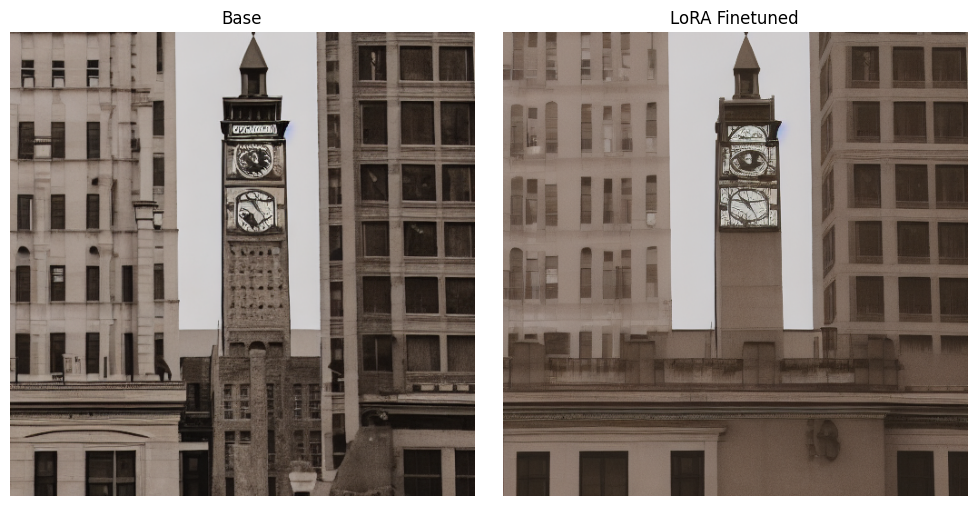

In [40]:
# sanity check
import numpy as np

prompt = prompts[20]
img1 = gen_image(pipe_base, prompt, seed=42)
img2 = gen_image(pipe_ft,   prompt, seed=42)

arr1 = np.array(img1).astype(float)
arr2 = np.array(img2).astype(float)

print(f"Pixel max diff:  {np.abs(arr1-arr2).max():.2f}")
print(f"Pixel mean diff: {np.abs(arr1-arr2).mean():.4f}")
print(f"Base score:      {score_pil(img1):.4f}")
print(f"Finetuned score: {score_pil(img2):.4f}")
print(f"LoRA params:     {len([n for n,p in pipe_ft.unet.named_parameters() if 'lora' in n])}")

fig, axes = plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(img1); axes[0].set_title("Base"); axes[0].axis("off")
axes[1].imshow(img2); axes[1].set_title("LoRA Finetuned"); axes[1].axis("off")
plt.tight_layout(); plt.show()